In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import src
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rc("text", usetex=True)
mpl.rc("font", family="serif")

/Users/gperaza/Research/informal-jobs-model/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Economic Sector Assignment

A substantial share of workers in the OD survey has no observed economic sector, so the objective of this stage is to estimate

$$P(S=s\mid X),$$

where $S$ denotes one of the four economic sectors and $X$ contains the available sociodemographic and labor characteristics.

Initially, the sector was predicted using models trained on ENOE and transferred to OD, selecting models mainly through balanced accuracy and assigning each worker to the most likely sector,

$$\hat{s}_i=\arg\max_s P(S_i=s\mid X_i).$$

Although this approach showed some individual signal, it transferred poorly between surveys and produced strongly distorted aggregate distributions, particularly by overassigning `gobierno_otro_agricultura` and underassigning `servicios_transporte`. We therefore tested models trained directly on OD workers with observed sector and found that OD-specific predictors, especially the original detailed occupation variable, provided better information than the previously harmonized predictors. We also replaced artificial class balancing and hard-classification-oriented model selection with probability estimation using survey expansion factors and weighted multiclass log loss,

$$\mathcal{L}=-\frac{\sum_i w_i\log P(S_i=s_i\mid X_i)}{\sum_i w_i}.$$

Two specifications were evaluated: one including education and another excluding it, since education is missing for a large share of the workers whose sector must be imputed (the share is reported in the hybrid-model section below). The final procedure therefore uses a hybrid model: $P(S\mid X,\text{education})$ when education is observed and $P(S\mid X)$ when it is unavailable. The four predicted sector probabilities are retained, allowing aggregate sector employment to be estimated as

$$\hat{N}_s=\sum_i w_iP(S_i=s\mid X_i).$$

This probabilistic approach reproduced the held-out OD sector distribution closely and is therefore used for the final economic-sector imputation.

To achieve the above, we first determine the number of workers with a known economic sector, as these are the ones we will use as training and testing data for the model; and we determine the number of workers with an unknown economic sector, as these are the ones to whom an economic sector will be assigned. 

In [2]:
od = pd.read_parquet(ROOT / "outputs/od_harmonized.parquet")
print(f"OD workers: {len(od):,}")
print(f"Workers with known sector: {(~od['sector_desconocido']).sum():,}")
print(f"Workers with unknown sector: {od['sector_desconocido'].sum():,}")

OD workers: 26,913
Workers with known sector: 17,429
Workers with unknown sector: 9,484


## Sector missingness profiles

We first compare the weighted characteristics of workers with observed and missing economic sector. This allows us to identify differences between the training population and the population for which sector must be imputed.

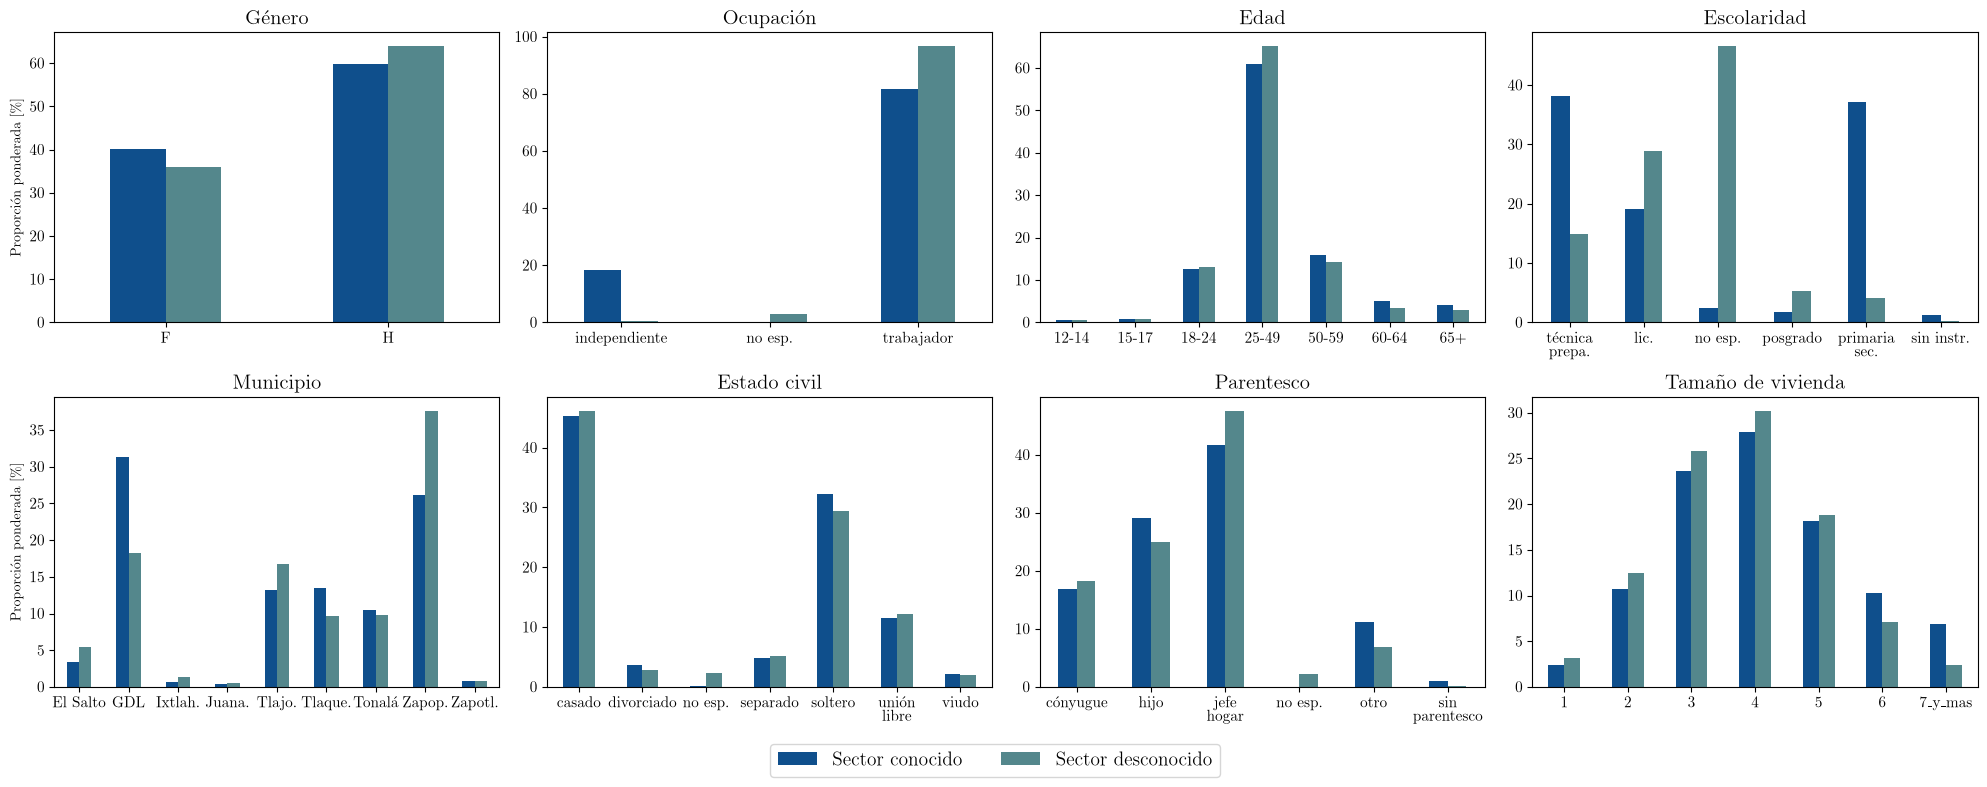

In [3]:
profile_columns = ["genero", "ocupacion", "edad_cat", "escolaridad", "municipio", "estado_civil", "parentesco", "tamano_viv_cat"]

sector_missingness_profiles = src.compare_sector_known_unknown_profiles(od, profile_columns)

plot_titles = {
    "genero": "Género",
    "ocupacion": "Ocupación",
    "edad_cat": "Edad",
    "escolaridad": "Escolaridad",
    "municipio": "Municipio",
    "estado_civil": "Estado civil",
    "parentesco": "Parentesco",
    "tamano_viv_cat": "Tamaño de vivienda"
}

tick_labels = {
    "ocupacion": {
        "independiente": "independiente",
        "no_especificado": "no esp.",
        "otro": "otro",
        "trabajador": "trabajador"
    },
    "escolaridad": {
        "carrera_tecnica_o_preparatoria": "técnica\nprepa.",
        "primaria_o_secundaria": "primaria\nsec.",
        "licenciatura": "lic.",
        "postgrado": "posgrado",
        "sin_instruccion": "sin instr.",
        "no_especificado": "no esp."
    },
    "edad_cat": {
        "25_49": "25-49",
        "18_24": "18-24",
        "15_17": "15-17",
        "50_59": "50-59",
        "65_y_mas": "65+",
        "60_64": "60-64",
        "12_14": "12-14"
    },
    "municipio": {
        "el_salto": "El Salto",
        "guadalajara": "GDL",
        "ixtlahuacan_membrillos": "Ixtlah.",
        "juanacatlan": "Juana.",
        "tlajomulco": "Tlajo.",
        "tlaquepaque": "Tlaque.",
        "tonala": "Tonalá",
        "zapopan": "Zapop.",
        "zapotlanejo": "Zapotl."
    },
    "estado_civil": {
        "casado": "casado",
        "divorciado": "divorciado",
        "no_especificado": "no esp.",
        "separado": "separado",
        "soltero": "soltero",
        "union_libre": "unión\nlibre",
        "viudo": "viudo"
    },
    "parentesco": {
        "conyuge": "cónyugue",
        "hijo": "hijo",
        "jefe_del_hogar": "jefe\nhogar",
        "no_especificado": "no esp.",
        "otro_parentesco": "otro",
        "sin_parentesco": "sin\nparentesco"
    },
    "tamano_viv_cat": {
        "1": "1",
        "2": "2",
        "3": "3",
        "4": "4",
        "5": "5",
        "6": "6",
        "7": "7",
        "8": "8",
        "9": "9",
        "10_y_mas": "10+"
    }
}

known_color = (0.06, 0.31, 0.55)
unknown_color = (0.33, 0.53, 0.55)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, (ax, variable) in enumerate(zip(axes.flatten(), profile_columns)):
    plot_data = sector_missingness_profiles[sector_missingness_profiles["variable"] == variable].copy()
    plot_data = plot_data.set_index("category")[["known_share", "unknown_share"]] * 100

    if variable in tick_labels:
        plot_data = plot_data.rename(index=tick_labels[variable])

    plot_data.plot(kind="bar", ax=ax, color=[known_color, unknown_color])

    ax.set_title(plot_titles[variable], fontsize=15)
    ax.set_xlabel("")

    if i in [0, 4]:
        ax.set_ylabel(r"Proporción ponderada [\%]")
    else:
        ax.set_ylabel("")

    ax.tick_params(axis="x", rotation=0, labelsize=11)
    ax.tick_params(axis="y", labelsize=11)

    ax.get_legend().remove()

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, ["Sector conocido", "Sector desconocido"], loc="lower center", ncol=2, fontsize=14, bbox_to_anchor=(0.5, 0.01))

output_dir = ROOT / "outputs/figures"
output_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout(rect=[0, 0.07, 1, 1])

fig.savefig(output_dir / "sector_known_unknown_profiles.pdf", bbox_inches="tight")
fig.savefig(output_dir / "sector_known_unknown_profiles.png", dpi=600, bbox_inches="tight")

plt.show()

In this graph, we can see that sector missingness is not uniformly distributed across worker characteristics. The largest differences are found in occupation and educational level: workers with an unknown sector are predominantly classified as `trabajador` and have a substantially higher proportion of unspecified education. Relevant differences are also observed across municipalities, particularly Guadalajara and Zapopan. In contrast, gender, age, and marital status show relatively similar distributions between workers with known and unknown sectors. These differences indicate a degree of distribution shift between the population available for model training and the population for which sector must be imputed, which should be considered when evaluating the model and its subsequent predictions.

## OD predictors

Because the economic-sector model will be trained and applied entirely within the OD survey, we can use detailed OD-specific variables that do not have direct ENOE equivalents. In particular, the original occupation variable retains considerably more information than the harmonized occupation category.

Considering the substantial discrepancy observed in the education attribute, we define two feature sets: one that includes education and another that excludes it. This allows the sector-imputation model to remain applicable to workers for whom educational information is unavailable.

In [4]:
with_education_features = src.OD_SECTOR_FEATURES
without_education_features = src.OD_ROBUST_SECTOR_FEATURES
print("With education:")
print(*with_education_features, sep="\n")
print("\nWithout education:")
print(*without_education_features, sep="\n")

With education:
genero
edad_num
escolaridad
municipio
estado_civil
parentesco
tamano_viv_cat
ocupacion_raw
trabajo_semana_pasada
centralidad
destino_trabajo
destino_ambito
dest_establecimientos_log
dest_share_grandes
dest_share_comercio
dest_share_gobierno_otro_agricultura
dest_share_manufactura_construccion
dest_share_servicios_transporte
modo_trabajo
weekend_dest_trabajar
n_autos_camionetas

Without education:
genero
edad_num
municipio
estado_civil
parentesco
tamano_viv_cat
ocupacion_raw
trabajo_semana_pasada
centralidad
destino_trabajo
destino_ambito
dest_establecimientos_log
dest_share_grandes
dest_share_comercio
dest_share_gobierno_otro_agricultura
dest_share_manufactura_construccion
dest_share_servicios_transporte
modo_trabajo
weekend_dest_trabajar
n_autos_camionetas


## Predictor missingness

Once we have defined the predictors, we need to analyze how available they are for the training and test sets.

In [5]:
feature_missingness = src.calculate_od_sector_feature_missingness(od, sector_features=with_education_features)
feature_missingness

,variable,known_missing_share,unknown_missing_share
0,genero,0.000000,0.000000
1,edad_num,0.000000,0.000000
2,escolaridad,0.025019,0.465404
3,municipio,0.000000,0.000000
4,estado_civil,0.001839,0.024018
5,parentesco,0.000000,0.021755
6,tamano_viv_cat,0.000000,0.000000
7,ocupacion_raw,0.000000,0.002910
8,trabajo_semana_pasada,0.000000,0.000000
9,centralidad,0.000000,0.000000


Here we can see that most of the predictors are nearly complete, with some attributes showing relatively small differences, but these do not limit the model (with the exception of the education attribute, which is why we chose to generate a model both with and without this variable). 

## Common OD train-test split

Workers with an observed economic sector are divided into a training sample and a held-out test sample. With n_splits=5, the procedure produces an approximately 80%–20% train-test division. The split is performed at the household level, ensuring that members of the same household cannot appear in both training and testing data, since individuals belonging to the same household cannot be considered completely independent observations.

Since the target variable is the economic sector, we use StratifiedGroupKFold, attempting to preserve the relative distribution of the four economic-sector classes across the partitions while keeping all members of each household within the same fold. 

In [6]:
od_sector_train, od_sector_test = src.split_od_sector_known_data(od, n_splits=5, test_fold=0, random_state=42)
print(f"OD workers available for training: {len(od_sector_train):,}")
print(f"OD workers reserved for testing: {len(od_sector_test):,}")
print(f"Training households: {od_sector_train['folio_vivienda'].nunique():,}")
print(f"Testing households: {od_sector_test['folio_vivienda'].nunique():,}")

OD workers available for training: 13,942
OD workers reserved for testing: 3,487
Training households: 8,112
Testing households: 2,051


## Model A: OD-specific predictors with education

For the first model (the one that includes the education variable), we prepare the data from the OD training set with a known class in the format required to train the classifiers. Here we obtain the **predictor matrix** $X$ containing the features (from `src.OD_SECTOR_FEATURES`) that the model will use to learn the economic sector; the **target variable** $y$ with four classes: `comercio`, `gobierno_otro_agricultura`, `manufactura_construccion` and `servicios_transporte`; the **weights** associated with the **expansion factor** that ensure that, during training and evaluation, an observation representing a larger portion of the population carries more weight than another $^*$; the **household groups**, which are used in cross-validation to ensure that people belonging to the same household always remain within the same fold; and the and the **final dataframe** of workers who actually participate in the **training**.

$^{*}$ The weights are normalized so that their absolute values fall within the range $[0,1]$, while preserving the relative proportions among the observations.

In [7]:
X_with_education, y_with_education, weights_with_education, groups_with_education, training_with_education = src.prepare_od_probabilistic_sector_training_data(od_sector_train, sector_features=with_education_features)
print(f"Workers used for training: {len(training_with_education):,}")
print(f"Households used for training: {groups_with_education.nunique():,}")

Workers used for training: 13,942
Households used for training: 8,112


Next, we train models and evaluate candidates. Here, we determine which family of algorithms performs best and which hyperparameters work best within each algorithm.



In [8]:
from IPython.display import Markdown
models = src.build_probabilistic_sector_models()
lines = []
for name, config in models.items():
    grid = config["params"]; n = 1
    for values in grid.values(): n *= len(values)
    tuned = ", ".join(f"`{key.replace('classifier__', '')}`: {values}" for key, values in grid.items())
    lines.append(f"* **{name}** — tuned: {tuned} — configurations: {n}")
total = sum(int(__import__("math").prod(len(v) for v in c["params"].values())) for c in models.values())
text = "The candidate families and their grids (read from `src.src.build_probabilistic_sector_models`, so this list cannot drift from the code):\n\n" + "\n".join(lines) + f"\n\nIn total {total} configurations, each evaluated with 5-fold household-grouped `StratifiedGroupKFold` ({total * 5} fits). Gradient boosting runs without early stopping (its internal validation split ignores households); the number of iterations is tuned in the grouped CV instead. Within each family, and then across families, the simplest configuration whose paired fold-difference to the best is within one standard error is selected (`src.select_one_se`)."

display(Markdown(text))

The candidate families and their grids (read from `src.src.build_probabilistic_sector_models`, so this list cannot drift from the code):

* **LogisticRegression** — tuned: `C`: [0.1, 1.0, 10.0] — configurations: 3
* **RandomForest** — tuned: `max_leaf_nodes`: [25, 50, 100], `max_features`: ['sqrt', 0.7], `min_samples_leaf`: [1, 5, 10] — configurations: 18
* **GradientBoosting** — tuned: `max_iter`: [50, 100, 200, 400], `learning_rate`: [0.05, 0.1], `max_leaf_nodes`: [15, 31], `l2_regularization`: [0.0, 1.0] — configurations: 32

In total 53 configurations, each evaluated with 5-fold household-grouped `StratifiedGroupKFold` (265 fits). Gradient boosting runs without early stopping (its internal validation split ignores households); the number of iterations is tuned in the grouped CV instead. Within each family, and then across families, the simplest configuration whose paired fold-difference to the best is within one standard error is selected (`src.select_one_se`).

As part of the preprocessing, age (`edad_num`) is treated as a numerical variable, while the remaining predictors are treated as categorical variables. Missing categorical values are represented as no_especificado, and categorical predictors are transformed using one-hot encoding. For Logistic Regression, the numerical variable is additionally standardized.

It is important to distinguish survey weighting from class balancing. The OD `expansion_factor` is used as a sample weight so that observations contribute according to the population they represent. However, no additional artificial class balancing is applied (`class_weight=None`), meaning that minority economic sectors are not artificially upweighted during training.

Because the objective is not only to assign a sector to each worker but also to obtain meaningful probabilities for all four sectors, model selection is primarily based on the weighted multiclass log loss:

$$\mathcal{L}=-\frac{\sum_i w_i\log P(y_i)}{\sum_i w_i},$$

where $w_i$ is the expansion factor associated with observation $i$, and $P(y_i)$ is the probability assigned by the model to its true economic sector. Lower values of $\mathcal{L}$ indicate better probabilistic predictions.

After evaluating all candidate configurations, the resulting summary reports:
- algorithm
- weighted log loss
- standard deviation
- weighted balanced accuracy
- weighted accuracy
- weighted macro F1
- best hyperparameters

In [9]:
with_education_summary, with_education_models = src.tune_probabilistic_sector_models(X_with_education, y_with_education, weights_with_education, groups_with_education, sector_features=with_education_features, cv_splits=5, random_state=42)
with_education_summary

,model,weighted_log_loss,weighted_log_loss_std,weighted_balanced_accuracy,weighted_accuracy,weighted_f1_macro,best_params,fold_log_losses,mean_diff_vs_best,se_diff_vs_best,within_one_se,complexity_rank,selected
0,GradientBoosting,0.876472,0.012707,0.552620,0.632860,0.566519,"{'classifier__l2_regularization': 1.0, 'classi...","[0.8567960924278376, 0.891315082920836, 0.8891...",0.000000,0.000000,True,3,True
1,RandomForest,0.891347,0.010396,0.501679,0.617064,0.504240,"{'classifier__max_features': 0.7, 'classifier_...","[0.8726240550052666, 0.902098519539623, 0.8995...",0.014876,0.001834,False,2,False
2,LogisticRegression,0.904778,0.011800,0.505749,0.605699,0.511241,{'classifier__C': 0.1},"[0.8885262601970706, 0.9202068519711958, 0.907...",0.028307,0.003493,False,1,False


In [10]:
with_education_best_name, with_education_best_model = src.get_best_probabilistic_sector_model(with_education_summary, with_education_models)
print(f"Best model with education: {with_education_best_name}")
print(with_education_summary.loc[with_education_summary["model"] == with_education_best_name, "best_params"].iloc[0])

Best model with education: GradientBoosting
{'classifier__l2_regularization': 1.0, 'classifier__learning_rate': 0.05, 'classifier__max_iter': 100, 'classifier__max_leaf_nodes': 31}


In [11]:
# Per-fold log losses of the selected configuration of each family (same household folds; the sd across folds is
# fold-to-fold variability, not a standard error of the mean)
src.fold_table(with_education_summary).round(4)

,fold_0,fold_1,fold_2,fold_3,fold_4,mean,sd_across_folds
GradientBoosting,0.8568,0.8913,0.8892,0.8745,0.8706,0.8765,0.0142
RandomForest,0.8726,0.9021,0.8995,0.8931,0.8894,0.8913,0.0116
LogisticRegression,0.8885,0.9202,0.9076,0.9134,0.8942,0.9048,0.0132


Now, we take the best model (Random Forest with the optimal hyperparameter settings) and apply it to the test data.

In [12]:
with_education_metrics, with_education_class_metrics, with_education_confusion, with_education_distribution = src.evaluate_probabilistic_sector_model(with_education_best_model, od_sector_test, sector_features=with_education_features)
with_education_metrics.round(4)

,accuracy,balanced_accuracy,f1_macro,weighted_accuracy,weighted_balanced_accuracy,weighted_f1_macro,weighted_log_loss
0,0.6455,0.5735,0.589,0.6517,0.5813,0.5981,0.8397


In [13]:
# Held-out metrics with household-bootstrap 95% intervals (500 resamples of test households) and the honest baseline:
# the weighted-marginal predictor (constant class shares), not the uniform log(4).
with_education_uncertainty = src.sector_test_metrics_with_uncertainty(with_education_best_model, od_sector_test, sector_features=with_education_features)
with_education_uncertainty.round(4)

,estimate,ci_low,ci_high,bootstrap_sd
weighted_log_loss,0.8397,0.8000,0.8767,0.0194
marginal_log_loss,1.2134,1.1897,1.2354,0.0117
weighted_accuracy,0.6517,0.6310,0.6738,0.0112
weighted_f1_macro,0.5981,0.5664,0.6304,0.0164
relative_improvement_over_marginal,0.3080,NaN,NaN,NaN


In [14]:
from IPython.display import Markdown
m = with_education_metrics.iloc[0]; u = with_education_uncertainty; cv = with_education_summary.loc[with_education_summary["selected"]].iloc[0]
text = (f"The selected **{with_education_best_name}** reaches a weighted accuracy of {m['weighted_accuracy']:.1%} on the held-out households "
        f"(95% household-bootstrap interval {u.loc['weighted_accuracy', 'ci_low']:.1%}–{u.loc['weighted_accuracy', 'ci_high']:.1%}). The lower weighted balanced accuracy ({m['weighted_balanced_accuracy']:.1%}) "
        f"and macro F1 ({m['weighted_f1_macro']:.3f}) show that performance is uneven across sectors, particularly for the minority class. "
        f"The weighted log loss of {m['weighted_log_loss']:.4f} [{u.loc['weighted_log_loss', 'ci_low']:.4f}, {u.loc['weighted_log_loss', 'ci_high']:.4f}] is {u.loc['relative_improvement_over_marginal', 'estimate']:.1%} below the weighted-marginal baseline "
        f"({u.loc['marginal_log_loss', 'estimate']:.4f}, the constant predictor that outputs the observed class shares — the honest reference, unlike the uniform log(4) = 1.386) and close to the cross-validation value ({cv['weighted_log_loss']:.4f}), so the out-of-sample probabilistic performance is stable.")
display(Markdown(text))

The selected **GradientBoosting** reaches a weighted accuracy of 65.2% on the held-out households (95% household-bootstrap interval 63.1%–67.4%). The lower weighted balanced accuracy (58.1%) and macro F1 (0.598) show that performance is uneven across sectors, particularly for the minority class. The weighted log loss of 0.8397 [0.8000, 0.8767] is 30.8% below the weighted-marginal baseline (1.2134, the constant predictor that outputs the observed class shares — the honest reference, unlike the uniform log(4) = 1.386) and close to the cross-validation value (0.8765), so the out-of-sample probabilistic performance is stable.

In [15]:
with_education_class_metrics.round(4)

,sector,precision,recall,f1,weighted_support
0,comercio,0.6916,0.7459,0.7177,112348.0
1,gobierno_otro_agricultura,0.5811,0.3202,0.4129,12857.0
2,manufactura_construccion,0.6708,0.6961,0.6832,82261.0
3,servicios_transporte,0.5956,0.5629,0.5788,112462.0


In [16]:
from IPython.display import Markdown
cm = with_education_class_metrics.set_index("sector"); rare = cm["recall"].idxmin(); share = cm.loc[rare, "weighted_support"] / cm["weighted_support"].sum()
others = cm.drop(index=rare)["f1"]
text = (f"Class-level metrics differ across sectors: {', '.join(others.index)} have F1 between {others.min():.2f} and {others.max():.2f}, whereas `{rare}`, only {share:.1%} of the weighted test population, has a recall of {cm.loc[rare, 'recall']:.1%} "
        f"(precision {cm.loc[rare, 'precision']:.1%}). The hard classifier — assigning each worker to the most probable class — rarely selects this minority sector, which explains the lower balanced accuracy and macro F1 and motivates keeping the full probability vector rather than a hard assignment.")
display(Markdown(text))

Class-level metrics differ across sectors: comercio, manufactura_construccion, servicios_transporte have F1 between 0.58 and 0.72, whereas `gobierno_otro_agricultura`, only 4.0% of the weighted test population, has a recall of 32.0% (precision 58.1%). The hard classifier — assigning each worker to the most probable class — rarely selects this minority sector, which explains the lower balanced accuracy and macro F1 and motivates keeping the full probability vector rather than a hard assignment.

In [17]:
with_education_distribution.round(4)

,sector,observed_population,observed_share,hard_predicted_population,hard_predicted_share,probabilistic_predicted_population,probabilistic_predicted_share,probabilistic_difference_pp
0,comercio,112348,0.3512,121173.0,0.3788,111765.5586,0.3493,-0.1821
1,gobierno_otro_agricultura,12857,0.0402,7085.0,0.0221,11392.5905,0.0356,-0.4577
2,manufactura_construccion,82261,0.2571,85369.0,0.2668,82303.9498,0.2573,0.0134
3,servicios_transporte,112462,0.3515,106301.0,0.3323,114465.9010,0.3578,0.6264


In [18]:
from IPython.display import Markdown
d = with_education_distribution.set_index("sector"); prob_col = [col for col in d.columns if "prob" in col and "share" in col][0]
prob_gap = (d[prob_col] - d["observed_share"]).abs().max() * 100; hard_gap = (d["hard_predicted_share"] - d["observed_share"]).abs().max() * 100
text = (f"Hard assignments distort the aggregate composition (largest deviation from the observed shares: {hard_gap:.1f} percentage points), whereas the probabilistic aggregation reproduces it: the largest deviation across the four sectors is {prob_gap:.1f} percentage points. "
        "Retaining the predicted probabilities is therefore the appropriate way to estimate population-level sector distributions.")
display(Markdown(text))

Hard assignments distort the aggregate composition (largest deviation from the observed shares: 2.8 percentage points), whereas the probabilistic aggregation reproduces it: the largest deviation across the four sectors is 0.6 percentage points. Retaining the predicted probabilities is therefore the appropriate way to estimate population-level sector distributions.

## Model B: OD-specific predictors without education

Moving on now to the model that does not consider the “education” attribute as a predictor, we begin by preparing the data in the same way we did for Model A, but now using the `src.OD_ROBUST_SECTOR_FEATURES` predictors.

In [19]:
X_without_education, y_without_education, weights_without_education, groups_without_education, training_without_education = src.prepare_od_probabilistic_sector_training_data(od_sector_train, sector_features=without_education_features)
print(f"Workers used for training: {len(training_without_education):,}")
print(f"Households used for training: {groups_without_education.nunique():,}")

Workers used for training: 13,942
Households used for training: 8,112


As for the machine learning models, we used the same ones as for A, with the same hyperparameters, my settings, and the same effectiveness metric. 

In [20]:
without_education_summary, without_education_models = src.tune_probabilistic_sector_models(X_without_education, y_without_education, weights_without_education, groups_without_education, sector_features=without_education_features, cv_splits=5, random_state=42)
without_education_summary

,model,weighted_log_loss,weighted_log_loss_std,weighted_balanced_accuracy,weighted_accuracy,weighted_f1_macro,best_params,fold_log_losses,mean_diff_vs_best,se_diff_vs_best,within_one_se,complexity_rank,selected
0,GradientBoosting,0.883856,0.009858,0.533801,0.623268,0.545629,"{'classifier__l2_regularization': 0.0, 'classi...","[0.865536978705376, 0.8886624688790938, 0.8950...",0.000000,0.000000,True,3,True
1,RandomForest,0.897734,0.011679,0.504274,0.618120,0.510501,"{'classifier__max_features': 0.7, 'classifier_...","[0.876583238752218, 0.9051730032320613, 0.9102...",0.013878,0.001449,False,2,False
2,LogisticRegression,0.914101,0.010463,0.499187,0.607051,0.500951,{'classifier__C': 0.1},"[0.8959241271319911, 0.9230889203655276, 0.922...",0.030245,0.002300,False,1,False


In [21]:
without_education_best_name, without_education_best_model = src.get_best_probabilistic_sector_model(without_education_summary, without_education_models)
print(f"Best model without education: {without_education_best_name}")
print(without_education_summary.loc[without_education_summary["model"] == without_education_best_name, "best_params"].iloc[0])

Best model without education: GradientBoosting
{'classifier__l2_regularization': 0.0, 'classifier__learning_rate': 0.05, 'classifier__max_iter': 50, 'classifier__max_leaf_nodes': 31}


In [22]:
# Per-fold log losses of the selected configuration of each family (same household folds; the sd across folds is
# fold-to-fold variability, not a standard error of the mean)
src.fold_table(without_education_summary).round(4)

,fold_0,fold_1,fold_2,fold_3,fold_4,mean,sd_across_folds
GradientBoosting,0.8655,0.8887,0.8950,0.8848,0.8852,0.8839,0.0110
RandomForest,0.8766,0.9052,0.9103,0.9016,0.8950,0.8977,0.0131
LogisticRegression,0.8959,0.9231,0.9220,0.9207,0.9087,0.9141,0.0117


Now, just as it was done with Model A we take the best model (Random Forest with the optimal hyperparameter settings) and apply it to the test data.

In [23]:
without_education_metrics, without_education_class_metrics, without_education_confusion, without_education_distribution = src.evaluate_probabilistic_sector_model(without_education_best_model, od_sector_test, sector_features=without_education_features)
without_education_metrics.round(4)

,accuracy,balanced_accuracy,f1_macro,weighted_accuracy,weighted_balanced_accuracy,weighted_f1_macro,weighted_log_loss
0,0.6318,0.5525,0.5713,0.6338,0.5658,0.5864,0.8622


In [24]:
# Held-out metrics with household-bootstrap 95% intervals (500 resamples of test households) and the honest baseline:
# the weighted-marginal predictor (constant class shares), not the uniform log(4).
without_education_uncertainty = src.sector_test_metrics_with_uncertainty(without_education_best_model, od_sector_test, sector_features=without_education_features)
without_education_uncertainty.round(4)

,estimate,ci_low,ci_high,bootstrap_sd
weighted_log_loss,0.8622,0.8272,0.8950,0.0171
marginal_log_loss,1.2134,1.1897,1.2354,0.0117
weighted_accuracy,0.6338,0.6131,0.6570,0.0113
weighted_f1_macro,0.5864,0.5488,0.6280,0.0205
relative_improvement_over_marginal,0.2894,NaN,NaN,NaN


In [25]:
from IPython.display import Markdown
a = with_education_metrics.iloc[0]; b = without_education_metrics.iloc[0]; ub = without_education_uncertainty
text = (f"Without education, weighted accuracy falls from {a['weighted_accuracy']:.1%} to {b['weighted_accuracy']:.1%} and weighted balanced accuracy from {a['weighted_balanced_accuracy']:.1%} to {b['weighted_balanced_accuracy']:.1%}; the weighted log loss rises from {a['weighted_log_loss']:.4f} to {b['weighted_log_loss']:.4f} "
        f"({ub.loc['relative_improvement_over_marginal', 'estimate']:.1%} below the marginal baseline instead of {with_education_uncertainty.loc['relative_improvement_over_marginal', 'estimate']:.1%}). Education carries useful information for the sector, but the loss is limited, so Model B is a reasonable fallback for workers without educational information.")
display(Markdown(text))

Without education, weighted accuracy falls from 65.2% to 63.4% and weighted balanced accuracy from 58.1% to 56.6%; the weighted log loss rises from 0.8397 to 0.8622 (28.9% below the marginal baseline instead of 30.8%). Education carries useful information for the sector, but the loss is limited, so Model B is a reasonable fallback for workers without educational information.

In [26]:
without_education_class_metrics.round(4)

,sector,precision,recall,f1,weighted_support
0,comercio,0.6631,0.7373,0.6983,112348.0
1,gobierno_otro_agricultura,0.6640,0.3118,0.4243,12857.0
2,manufactura_construccion,0.6558,0.6830,0.6691,82261.0
3,servicios_transporte,0.5784,0.5312,0.5538,112462.0


The class-level results show that removing education particularly affects the identification of the minority `gobierno_otro_agricultura` sector, which is no longer selected at all under hard classification. Commerce and manufacturing/construction also experience moderate reductions in recall and F1, while services/transport shows higher recall but lower precision. These results confirm that education contributes useful discriminatory information, especially for minority-sector identification.

In [27]:
without_education_distribution.round(4)

,sector,observed_population,observed_share,hard_predicted_population,hard_predicted_share,probabilistic_predicted_population,probabilistic_predicted_share,probabilistic_difference_pp
0,comercio,112348,0.3512,124920.0,0.3905,111769.8891,0.3494,-0.1807
1,gobierno_otro_agricultura,12857,0.0402,6038.0,0.0189,12369.4660,0.0387,-0.1524
2,manufactura_construccion,82261,0.2571,85681.0,0.2678,82046.6138,0.2565,-0.067
3,servicios_transporte,112462,0.3515,103289.0,0.3229,113742.0311,0.3555,0.4001


#### Calibration of the sector probabilities

The imputation is probabilistic, so what matters is whether the predicted probabilities are honest, not only whether the arg-max class is right. For each class we compare, on the held-out households, the weighted mean predicted probability with the weighted observed share (calibration in the large) and the reliability curve (observed share within bins of predicted probability). The expected calibration error (ECE) is the population-weighted mean absolute distance between the curve and the diagonal. Both specifications are shown.

Calibration in the large — with education
                   sector  observed_share  predicted_share  gap_pp    ece  calibration_slope
                 comercio          0.3512           0.3493 -0.1821 0.0226             0.9522
gobierno_otro_agricultura          0.0402           0.0356 -0.4577 0.0077             0.9844
 manufactura_construccion          0.2571           0.2573  0.0134 0.0176             1.0210
     servicios_transporte          0.3515           0.3578  0.6264 0.0274             0.7984

Calibration in the large — without education
                   sector  observed_share  predicted_share  gap_pp    ece  calibration_slope
                 comercio          0.3512           0.3494 -0.1807 0.0166             1.0316
gobierno_otro_agricultura          0.0402           0.0387 -0.1524 0.0108             1.1580
 manufactura_construccion          0.2571           0.2565 -0.0670 0.0209             1.1051
     servicios_transporte          0.3515           0.3555  0.4001 0.0216  

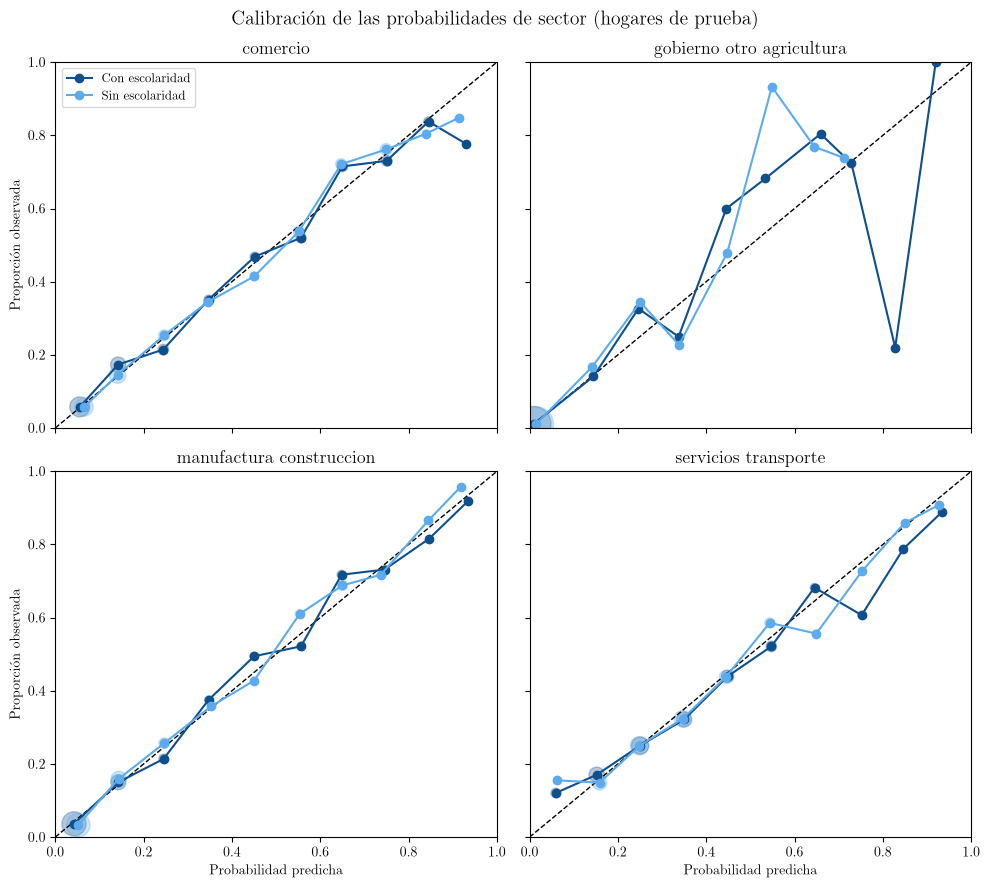

In [28]:
with_education_calibration_summary, with_education_reliability = src.calculate_sector_calibration(with_education_best_model, od_sector_test, sector_features=with_education_features)
without_education_calibration_summary, without_education_reliability = src.calculate_sector_calibration(without_education_best_model, od_sector_test, sector_features=without_education_features)
print("Calibration in the large — with education")
print(with_education_calibration_summary.round(4).to_string(index=False))
print("\nCalibration in the large — without education")
print(without_education_calibration_summary.round(4).to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(10, 9), sharex=True, sharey=True)
for ax, sector_class in zip(axes.ravel(), src.SECTOR_CLASSES):
    ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
    for label, reliability, color in (("Con escolaridad", with_education_reliability, (0.06, 0.31, 0.55)), ("Sin escolaridad", without_education_reliability, (0.36, 0.67, 0.93))):
        curve = reliability[reliability["sector"] == sector_class]
        ax.plot(curve["predicted_probability"], curve["observed_rate"], marker="o", color=color, label=label)
        ax.scatter(curve["predicted_probability"], curve["observed_rate"], s=curve["sample_workers"] / 5, color=color, alpha=0.3)
    ax.set_title(sector_class.replace("_", " "), fontsize=13)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
axes[1, 0].set_xlabel("Probabilidad predicha"); axes[1, 1].set_xlabel("Probabilidad predicha")
axes[0, 0].set_ylabel("Proporción observada"); axes[1, 0].set_ylabel("Proporción observada")
axes[0, 0].legend(fontsize=9)
fig.suptitle("Calibración de las probabilidades de sector (hogares de prueba)", fontsize=14)
plt.tight_layout()
output_dir = ROOT / "outputs/figures"
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "sector_calibration.pdf", bbox_inches="tight")
fig.savefig(output_dir / "sector_calibration.png", dpi=600, bbox_inches="tight")
plt.show()

In [29]:
from IPython.display import Markdown
d = without_education_distribution.set_index("sector"); prob_col = [col for col in d.columns if "prob" in col and "share" in col][0]
prob_gap = (d[prob_col] - d["observed_share"]).abs().max() * 100; hard_gap = (d["hard_predicted_share"] - d["observed_share"]).abs().max() * 100; rare_hard = d.loc["gobierno_otro_agricultura", "hard_predicted_share"]
text = (f"Model B's hard predictions distort the aggregate distribution (largest deviation {hard_gap:.1f} percentage points; `gobierno_otro_agricultura` receives {rare_hard:.1%} of the hard assignments), while its probabilistic aggregation stays within {prob_gap:.1f} percentage points of the observed shares — "
        "similar to Model A. Removing education lowers individual classification performance, but Model B remains a suitable probabilistic fallback.")
display(Markdown(text))

Model B's hard predictions distort the aggregate distribution (largest deviation 3.9 percentage points; `gobierno_otro_agricultura` receives 1.9% of the hard assignments), while its probabilistic aggregation stays within 0.4 percentage points of the observed shares — similar to Model A. Removing education lowers individual classification performance, but Model B remains a suitable probabilistic fallback.

## Model comparison

In [30]:
model_comparison = pd.concat([with_education_metrics.assign(features="Con escolaridad"), without_education_metrics.assign(features="Sin escolaridad")], ignore_index=True)
model_comparison = model_comparison[["features", "weighted_accuracy", "weighted_balanced_accuracy", "weighted_f1_macro", "weighted_log_loss"]]
model_comparison.round(4)

,features,weighted_accuracy,weighted_balanced_accuracy,weighted_f1_macro,weighted_log_loss
0,Con escolaridad,0.6517,0.5813,0.5981,0.8397
1,Sin escolaridad,0.6338,0.5658,0.5864,0.8622


Model A consistently outperforms Model B, confirming that education provides useful predictive information. However, the performance reduction when education is excluded remains moderate, and both models reproduce the aggregate sector distribution well when probabilistic predictions are used. Therefore, we adopt a hybrid strategy: Model A is used when education is available, while Model B serves as a fallback when it is missing.

## Hybrid sector model

The first step in constructing the hybrid sector model is to perform a final refit of the two selected models, this time using all OD workers whose economic sector is known. Since model selection and independent evaluation have already been completed, the previously held-out test observations can now be reincorporated into the training data.

For each model specification, we prepare the corresponding training data using all workers with an observed sector. We then create a clean copy of the selected model, preserving its model family, preprocessing pipeline, and optimal hyperparameters, but discarding the parameters previously learned from the training subset. Each model is then retrained from scratch using the complete set of workers with known economic sector.

In [31]:
final_with_education_model, final_with_education_training = src.refit_probabilistic_sector_model(with_education_best_model, od, sector_features=with_education_features)
final_without_education_model, final_without_education_training = src.refit_probabilistic_sector_model(without_education_best_model, od, sector_features=without_education_features)
print(f"Workers used for final training: {len(final_with_education_training):,}")
print(f"Households used for final training: {final_with_education_training['folio_vivienda'].nunique():,}")

Workers used for final training: 17,429
Households used for final training: 10,163


Now we generate the sector predictions using the hybrid model. For workers whose economic sector is unknown, we first check whether educational information is available. If it is, Model A is applied; otherwise, Model B is used. Workers with an observed sector retain their original classification.

For each worker requiring imputation, the selected model first estimates the probability of belonging to each of the four economic sectors. These probabilities are retained, and an individual sector classification is then assigned according to the sector with the highest predicted probability.

In [32]:
# Auxiliary models P(destino_trabajo | x) on OD workers with a work trip (review item 4.7): workers without a work trip
# are marginalized over destination types with their own conditional distribution instead of the global shares.
destination_models = src.fit_destination_models(od, with_education_features=with_education_features, without_education_features=without_education_features)
od_sector_imputed = src.impute_missing_sectors_hybrid(final_with_education_model, final_without_education_model, od, with_education_features=with_education_features, without_education_features=without_education_features, destination_models=destination_models)
print(f"Workers with observed sector: {(~od_sector_imputed['sector_fue_imputado']).sum():,}")
print(f"Workers with imputed sector: {od_sector_imputed['sector_fue_imputado'].sum():,}")
print(f"Workers without final sector: {od_sector_imputed['sector_final'].isna().sum():,}")

# Levels present in the OD rows being imputed but absent from the training rows have no training support:
# with explicit encoder categories they are scored on the remaining features instead of an all-zero block.
unsupported_levels = src.count_levels_without_training_support(src.prepare_sector_features(od[~od["sector_desconocido"]], with_education_features), src.prepare_sector_features(od[od["sector_desconocido"]], with_education_features))
print("\nImputed rows with categorical levels absent from the training data:")
display(unsupported_levels)

Workers with observed sector: 17,429
Workers with imputed sector: 9,484
Workers without final sector: 0

Imputed rows with categorical levels absent from the training data:


,feature,rows,levels
0,parentesco,105,[no_especificado]
1,ocupacion_raw,222,"[Desempleado, Estudiante, Hogar, Jubilado o pe..."


To analyze the results, we first look at how the workers were distributed across the two models.

In [33]:
model_usage = src.calculate_sector_model_usage(od_sector_imputed)
model_usage

,sector_model_used,sample_workers,weighted_population,sample_share,weighted_share
0,with_education,4962,366704,0.523197,0.534596
1,without_education,4522,319242,0.476803,0.465404


In [34]:
from IPython.display import Markdown
usage = model_usage.set_index("sector_model_used")
text = (f"Model A (with education) imputes {usage.loc['with_education', 'sample_workers']:,} workers ({usage.loc['with_education', 'weighted_share']:.1%} of the weighted population that needed imputation) and Model B the remaining {usage.loc['without_education', 'sample_workers']:,} ({usage.loc['without_education', 'weighted_share']:.1%}). "
        "The hybrid strategy is therefore not a corner case: close to half of the workers requiring a sector have no usable education and depend on Model B.")
display(Markdown(text))

Model A (with education) imputes 4,962 workers (53.5% of the weighted population that needed imputation) and Model B the remaining 4,522 (46.5%). The hybrid strategy is therefore not a corner case: close to half of the workers requiring a sector have no usable education and depend on Model B.

As a simple numerical check, we confirm that the sum of the four sectors equals 1.

In [35]:
maximum_probability_error = src.validate_sector_probability_rows(od_sector_imputed)
print(f"Maximum probability-sum error: {maximum_probability_error:.3e}")

Maximum probability-sum error: 2.220e-16


Now, we evaluate the resulting sector distributions and prediction confidence. We separately calculate the sector composition of the imputed workers and of the complete OD dataset using both hard classifications and probabilistic assignments. We also retain the observed-sector distribution as a reference and summarize the confidence of the predictions produced by the hybrid model.

In [36]:
imputed_workers = od_sector_imputed[od_sector_imputed["sector_fue_imputado"]].copy()

hard_imputed_distribution = src.calculate_sector_distribution(imputed_workers, sector_column="sector_final")
probabilistic_imputed_distribution = src.calculate_probabilistic_sector_distribution(imputed_workers)

hard_final_distribution = src.calculate_sector_distribution(od_sector_imputed, sector_column="sector_final")
probabilistic_final_distribution = src.calculate_probabilistic_sector_distribution(od_sector_imputed)

observed_distribution = src.calculate_sector_distribution(od[~od["sector_desconocido"]], sector_column="sector")

confidence_summary = src.calculate_sector_confidence_summary(od_sector_imputed)
confidence_summary.round(4)

,sector_model_used,count,mean,std,min,median,max
0,with_education,4962,0.6336,0.1360,0.3002,0.6331,0.9812
1,without_education,4522,0.6575,0.1316,0.2963,0.6550,0.9559


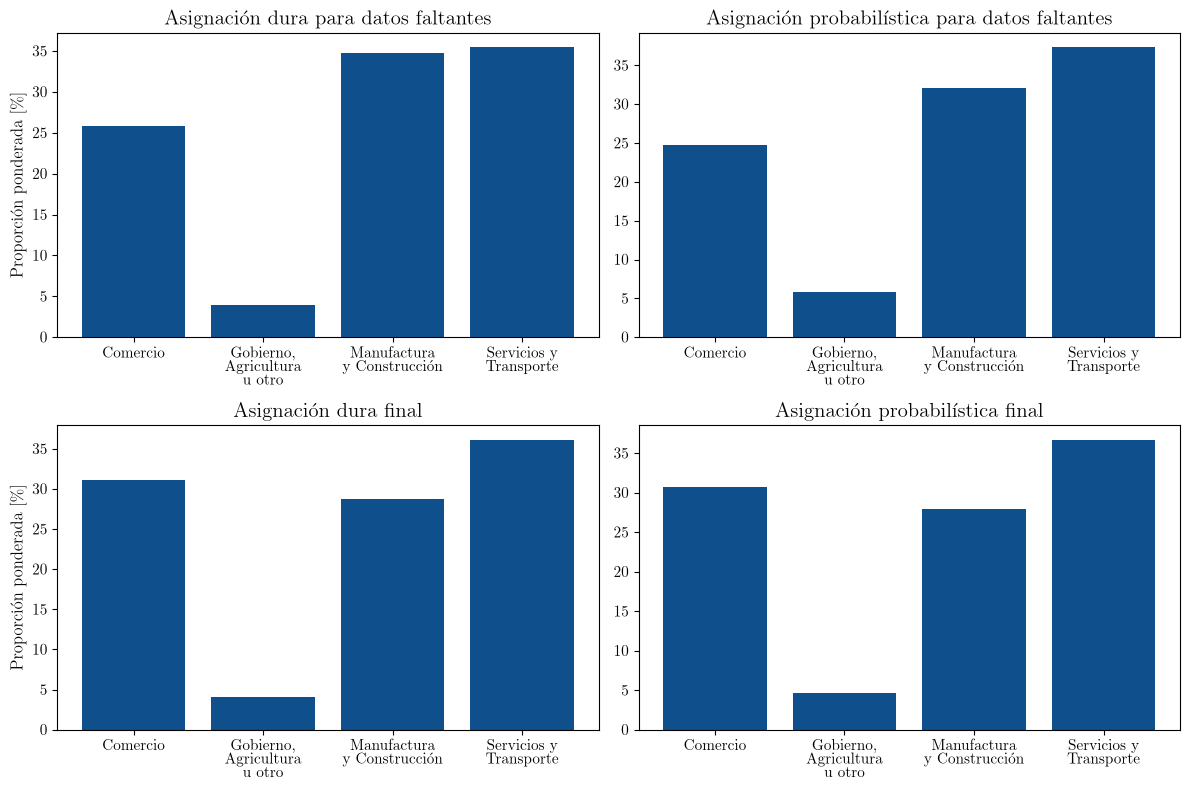

In [37]:
sector_labels = {
    "comercio": "Comercio",
    "gobierno_otro_agricultura": "Gobierno,\nAgricultura\nu otro",
    "manufactura_construccion": "Manufactura\ny Construcción",
    "servicios_transporte": "Servicios y\nTransporte"
}

plot_specs = [
    (hard_imputed_distribution.rename(columns={"sector_final": "sector"}), "weighted_share", "Asignación dura para datos faltantes"),
    (probabilistic_imputed_distribution, "weighted_share", "Asignación probabilística para datos faltantes"),
    (hard_final_distribution.rename(columns={"sector_final": "sector"}), "weighted_share", "Asignación dura final"),
    (probabilistic_final_distribution, "weighted_share", "Asignación probabilística final")
]

informality_color = (0.06, 0.31, 0.55)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, (ax, (df, share_col, title)) in enumerate(zip(axes.flatten(), plot_specs)):
    plot_data = df.copy()
    plot_data["sector"] = plot_data["sector"].replace(sector_labels)
    plot_data[share_col] = plot_data[share_col] * 100

    ax.bar(plot_data["sector"], plot_data[share_col], color=informality_color)

    ax.set_title(title, fontsize=15)
    ax.set_xlabel("")

    if i in [0, 2]:
        ax.set_ylabel(r"Proporción ponderada [\%]", fontsize=12)
    else:
        ax.set_ylabel("")

    ax.tick_params(axis="x", rotation=0, labelsize=11)
    ax.tick_params(axis="y", labelsize=11)

output_dir = ROOT / "outputs/figures"
output_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout()

fig.savefig(output_dir / "sector_imputation_distributions.pdf", bbox_inches="tight")
fig.savefig(output_dir / "sector_imputation_distributions.png", dpi=600, bbox_inches="tight")

plt.show()

The results show a substantial difference between hard and probabilistic sector assignments. Hard classification strongly concentrates imputed workers in `servicios_transporte` and nearly eliminates the minority `gobierno_otro_agricultura` sector. In contrast, probabilistic aggregation distributes the imputed population more smoothly across the four sectors and consequently produces a more balanced final OD sector composition. Given the superior aggregate performance observed previously on the held-out test set, the probabilistic distribution is therefore preferred for population-level analyses, while the hard assignment is retained when an individual sector classification is required.

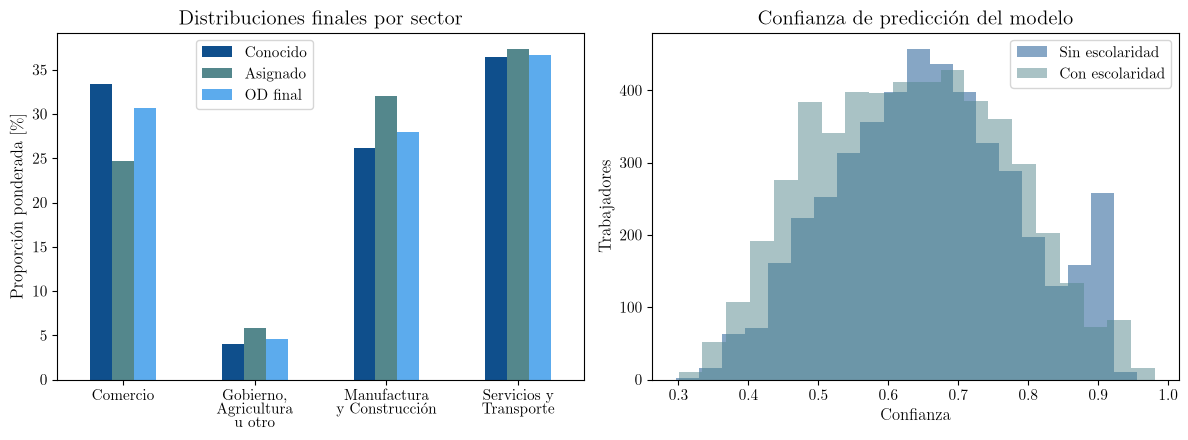

In [38]:
sector_labels = {
    "comercio": "Comercio",
    "gobierno_otro_agricultura": "Gobierno,\nAgricultura\nu otro",
    "manufactura_construccion": "Manufactura\ny Construcción",
    "servicios_transporte": "Servicios y\nTransporte"
}

known_color = (0.06, 0.31, 0.55)
assigned_color = (0.33, 0.53, 0.55)
final_color = (0.36, 0.67, 0.93)

observed_comparison = observed_distribution[["sector", "weighted_share"]].rename(columns={"weighted_share": "observed_known_share"})
observed_comparison = observed_comparison.merge(probabilistic_imputed_distribution[["sector", "weighted_share"]].rename(columns={"weighted_share": "imputed_share"}), on="sector", how="outer")
observed_comparison = observed_comparison.merge(probabilistic_final_distribution[["sector", "weighted_share"]].rename(columns={"weighted_share": "final_share"}), on="sector", how="outer")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

plot_data = observed_comparison.copy()
plot_data["sector"] = plot_data["sector"].replace(sector_labels)
plot_data = plot_data.set_index("sector")[["observed_known_share", "imputed_share", "final_share"]] * 100

plot_data.plot(kind="bar", ax=axes[0], color=[known_color, assigned_color, final_color])

axes[0].set_title("Distribuciones finales por sector", fontsize=15)
axes[0].set_xlabel("")
axes[0].set_ylabel(r"Proporción ponderada [\%]", fontsize=12)
axes[0].tick_params(axis="x", rotation=0, labelsize=11)
axes[0].tick_params(axis="y", labelsize=11)
axes[0].legend(["Conocido", "Asignado", "OD final"], fontsize=11, loc="upper right", bbox_to_anchor=(0.5, 1.0))

model_colors = {
    "without_education": known_color,
    "with_education": assigned_color
}

model_labels = {
    "without_education": "Sin escolaridad",
    "with_education": "Con escolaridad"
}

for model_name in ["without_education", "with_education"]:
    group = imputed_workers[imputed_workers["sector_model_used"] == model_name]
    axes[1].hist(group["sector_prediction_confidence"], bins=20, alpha=0.5, color=model_colors[model_name], label=model_labels[model_name])

axes[1].set_title("Confianza de predicción del modelo", fontsize=15)
axes[1].set_xlabel("Confianza", fontsize=12)
axes[1].set_ylabel("Trabajadores", fontsize=12)
axes[1].tick_params(axis="x", labelsize=11)
axes[1].tick_params(axis="y", labelsize=11)
axes[1].legend(fontsize=11)

output_dir = ROOT / "outputs/figures"
output_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout()

fig.savefig(output_dir / "sector_final_distributions_confidence.pdf", bbox_inches="tight")
fig.savefig(output_dir / "sector_final_distributions_confidence.png", dpi=600, bbox_inches="tight")

plt.show()

Prediction confidence remains relatively moderate for both components of the hybrid model, with most maximum predicted probabilities concentrated well below 0.5 (see the confidence summary above). This is consistent with the limited separability of the four economic sectors at the individual level and with the moderate classification performance observed on the held-out test set. However, low individual confidence does not preclude accurate population-level estimates: by retaining the complete probability vector for each worker, uncertainty is distributed across sectors and can aggregate to sector proportions that closely reproduce the observed distributions. Therefore, the model is better interpreted as a probabilistic population-allocation model than as a highly confident individual-level classifier.

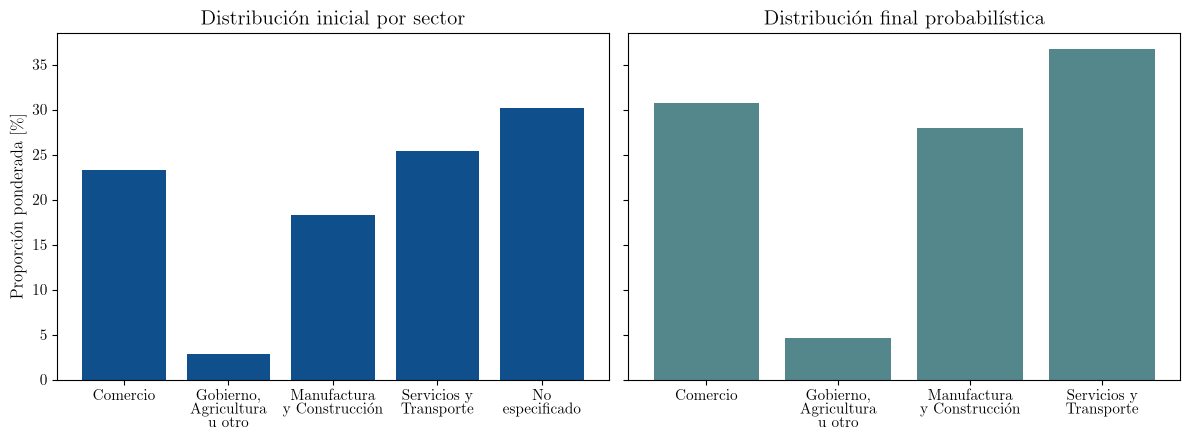

In [39]:
sector_labels = {
    "comercio": "Comercio",
    "gobierno_otro_agricultura": "Gobierno,\nAgricultura\nu otro",
    "manufactura_construccion": "Manufactura\ny Construcción",
    "servicios_transporte": "Servicios y\nTransporte",
    "no_especificado": "No\nespecificado"
}

sector_order_initial = ["comercio", "gobierno_otro_agricultura", "manufactura_construccion", "servicios_transporte", "no_especificado"]
sector_order_final = ["comercio", "gobierno_otro_agricultura", "manufactura_construccion", "servicios_transporte"]

known_color = (0.06, 0.31, 0.55)
final_color = (0.33, 0.53, 0.55)

initial_distribution = od.copy()
initial_distribution["sector"] = initial_distribution["sector"].fillna("no_especificado")
initial_distribution = initial_distribution.groupby("sector", as_index=False)["expansion_factor"].sum().rename(columns={"expansion_factor": "weighted_population"})
initial_distribution["weighted_share"] = initial_distribution["weighted_population"] / initial_distribution["weighted_population"].sum()
initial_distribution = initial_distribution.set_index("sector").reindex(sector_order_initial).reset_index()

final_distribution = probabilistic_final_distribution.set_index("sector").reindex(sector_order_final).reset_index()

initial_plot = initial_distribution.copy()
initial_plot["sector"] = initial_plot["sector"].replace(sector_labels)
initial_plot["weighted_share"] *= 100

final_plot = final_distribution.copy()
final_plot["sector"] = final_plot["sector"].replace(sector_labels)
final_plot["weighted_share"] *= 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

axes[0].bar(initial_plot["sector"], initial_plot["weighted_share"], color=known_color)
axes[0].set_title("Distribución inicial por sector", fontsize=15)
axes[0].set_xlabel("")
axes[0].set_ylabel(r"Proporción ponderada [\%]", fontsize=12)
axes[0].tick_params(axis="x", rotation=0, labelsize=11)
axes[0].tick_params(axis="y", labelsize=11)

axes[1].bar(final_plot["sector"], final_plot["weighted_share"], color=final_color)
axes[1].set_title("Distribución final probabilística", fontsize=15)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=0, labelsize=11)
axes[1].tick_params(axis="y", labelsize=11)

output_dir = ROOT / "outputs/figures"
output_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout()

fig.savefig(output_dir / "sector_initial_final_distribution.pdf", bbox_inches="tight")
fig.savefig(output_dir / "sector_initial_final_distribution.png", dpi=600, bbox_inches="tight")

plt.show()

Finally, we can see how we successfully assigned the unspecified attribute to the other sectors, while maintaining the original proportion among them. 

#### Sensitivity of the imputation to the covariate shift

Everything above validates the model on **known-sector** households, but it is applied to the **unknown-sector** workers, who differ: they are more educated and their missing sector co-occurs with missing education and other item non-response (a skipped questionnaire block). The imputation therefore rests on a missing-at-random-given-covariates (MAR) assumption: conditional on the features, the sector distribution of workers who did not answer is the same as that of workers who did. Two checks bound how much the result depends on it — neither changes the shipped output:

1. **Shift-weighted refit.** The known-sector training rows are reweighted to the covariate profile of the unknown-sector workers (density-ratio weights from a logistic classifier on the shared features, education excluded) and the selected models are refit and re-applied. Under MAR the imputed distribution should be essentially unchanged.
2. **Delta adjustment of the rare class.** `gobierno_otro_agricultura` is 4% of known-sector workers but the models assign it a larger share among imputed workers; the adjustment scales its imputed probability back to the observed share to show what the final distribution looks like if that excess is an artefact rather than a real difference.

Both scenarios are written to `outputs/od_sector_imputed_sensitivity.parquet` (column `scenario`) and carried into the informality stage, where the headline estimate is reported under each.

In [40]:
od_sector_shift, shift_diagnostics = src.impute_sectors_under_covariate_shift(with_education_best_model, without_education_best_model, od, with_education_features=with_education_features, without_education_features=without_education_features)
od_sector_delta, delta_factor = src.adjust_imputed_sector_share(od_sector_imputed, "gobierno_otro_agricultura")
print("Shift-weighting diagnostics (known-sector rows reweighted to the unknown-sector profile):")
print(shift_diagnostics.round(3).to_string())
print(f"\nDelta adjustment factor for gobierno_otro_agricultura among imputed workers: {delta_factor:.3f}")

def imputed_shares(frame):
    distribution = src.calculate_probabilistic_sector_distribution(frame[frame["sector_fue_imputado"]])
    return distribution.set_index("sector")["weighted_share"]
known_shares = src.calculate_sector_distribution(od_sector_imputed[~od_sector_imputed["sector_fue_imputado"]], sector_column="sector_final").set_index("sector_final")["weighted_share"]
sector_sensitivity = pd.DataFrame({"observed (known sector)": known_shares, "imputed: current": imputed_shares(od_sector_imputed), "imputed: shift-weighted": imputed_shares(od_sector_shift), "imputed: delta-adjusted": imputed_shares(od_sector_delta)}).reindex(src.SECTOR_CLASSES)
final_sensitivity = pd.DataFrame({name: src.calculate_probabilistic_sector_distribution(frame).set_index("sector")["weighted_share"] for name, frame in (("current", od_sector_imputed), ("shift-weighted", od_sector_shift), ("delta-adjusted", od_sector_delta))}).reindex(src.SECTOR_CLASSES)
print("\nSector shares among imputed workers (weighted):"); print((sector_sensitivity * 100).round(2))
print("\nFinal sector distribution, all workers (weighted):"); print((final_sensitivity * 100).round(2))

sensitivity_output = pd.concat([od_sector_shift.assign(scenario="shift_weighted"), od_sector_delta.assign(scenario="delta_adjusted")], ignore_index=True)
sensitivity_output.to_parquet(ROOT / "outputs/od_sector_imputed_sensitivity.parquet", index=False)

Shift-weighting diagnostics (known-sector rows reweighted to the unknown-sector profile):
rows                       17429.000
effective_sample_size       6870.056
top_decile_weight_share        0.188
odds_ratio_median              0.987
odds_ratio_p90                 2.257

Delta adjustment factor for gobierno_otro_agricultura among imputed workers: 0.692

Sector shares among imputed workers (weighted):
                           observed (known sector)  imputed: current  \
comercio                                     33.36             24.71   
gobierno_otro_agricultura                     4.05              5.86   
manufactura_construccion                     26.16             32.10   
servicios_transporte                         36.42             37.33   

                           imputed: shift-weighted  imputed: delta-adjusted  
comercio                                     23.58                    24.99  
gobierno_otro_agricultura                     5.94                     4.05

In [41]:
output_directory = ROOT / "outputs"
output_directory.mkdir(exist_ok=True)

output_path = output_directory / "od_sector_imputed.parquet"
od_sector_imputed.to_parquet(output_path, index=False)

In [42]:
from joblib import dump

models_directory = ROOT / "outputs/models"
models_directory.mkdir(parents=True, exist_ok=True)

sector_model_bundle = {
    "model_with_education": final_with_education_model,
    "model_without_education": final_without_education_model,
    "features_with_education": with_education_features,
    "features_without_education": without_education_features,
    "category_levels": src.build_category_levels(),
    "sector_classes": src.SECTOR_CLASSES,
    "destination_models": destination_models,
    "metadata": {
        "selected": {"with_education": with_education_summary.loc[with_education_summary["selected"], ["model", "best_params", "weighted_log_loss"]].iloc[0].to_dict(), "without_education": without_education_summary.loc[without_education_summary["selected"], ["model", "best_params", "weighted_log_loss"]].iloc[0].to_dict()},
        "test_metrics": {"with_education": with_education_metrics.iloc[0].to_dict(), "without_education": without_education_metrics.iloc[0].to_dict()},
        "sklearn_version": __import__("sklearn").__version__,
        "random_state": 42,
    }
}

model_path = models_directory / "economic_sector_hybrid_model.joblib"
dump(sector_model_bundle, model_path)

print(f"Saved: {model_path}")

Saved: /Users/gperaza/Research/informal-jobs-model/outputs/models/economic_sector_hybrid_model.joblib
